In [3]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("sklearn") is None:
    print("Installing scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
else:
    print("scikit-learn is already installed.")

scikit-learn is already installed.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
MAIN_METRICS_PATH = BASE_DIR / "Data" / "Cleaned" / "gdp_main_models_rebuilt_with_lag_metrics.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

TRAIN_END_YEAR = 2017
VALID_START_YEAR = 2016
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

MODEL_NAME = "Random Forest Model 3 - Full Dynamic"
MODEL_FAMILY = "Tree-based ML"
MODEL_NOTE = "Random Forest version of Model 3 with lag GDP, extra drivers, crisis dummies, region effects, and year trend."

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned


In [5]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def sanitize_feature_names(columns):
    clean_cols = []
    for col in columns:
        clean_col = (
            str(col)
            .replace(" ", "_")
            .replace("&", "and")
            .replace(",", "")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
            .replace("-", "_")
        )
        clean_cols.append(clean_col)
    return clean_cols


def build_prediction_frame(pred_df, predicted_log_values, model_name, family, note):
    out = pred_df.copy()

    out["model"] = model_name
    out["model_family"] = family
    out["model_note"] = note

    out["predicted_log_gdp_next_year"] = predicted_log_values
    out["actual_log_gdp_next_year"] = out["target_log_gdp_next_year"]

    out["predicted_gdp_next_year"] = np.exp(out["predicted_log_gdp_next_year"])
    out["actual_gdp_next_year"] = np.exp(out["actual_log_gdp_next_year"])

    out["feature_year"] = out["year"].astype(int)
    out["target_year"] = out["feature_year"] + 1

    out["absolute_error_usd"] = np.abs(
        out["actual_gdp_next_year"] - out["predicted_gdp_next_year"]
    )
    out["absolute_percentage_error_pct"] = (
        out["absolute_error_usd"] / out["actual_gdp_next_year"]
    ) * 100
    out["signed_percentage_error_pct"] = (
        (out["predicted_gdp_next_year"] - out["actual_gdp_next_year"])
        / out["actual_gdp_next_year"]
    ) * 100

    return out


def build_metrics_rows(train_pred_df, test_pred_df, model_name, family, note):
    rows = []

    for split_name, pred_df in [("train", train_pred_df), ("test", test_pred_df)]:
        level_metrics = regression_metrics(
            pred_df["actual_gdp_next_year"],
            pred_df["predicted_gdp_next_year"],
        )
        log_metrics = regression_metrics(
            pred_df["actual_log_gdp_next_year"],
            pred_df["predicted_log_gdp_next_year"],
        )

        rows.append(
            {
                "model": model_name,
                "model_family": family,
                "model_note": note,
                "split": split_name,
                "scale": "level_gdp_usd",
                "n_obs": len(pred_df),
                **level_metrics,
            }
        )
        rows.append(
            {
                "model": model_name,
                "model_family": family,
                "model_note": note,
                "split": split_name,
                "scale": "log_gdp",
                "n_obs": len(pred_df),
                **log_metrics,
            }
        )

    return pd.DataFrame(rows)


def build_yearly_summary(pred_df):
    rows = []
    for target_year, year_df in pred_df.groupby("target_year"):
        rows.append(
            {
                "target_year": int(target_year),
                "n_obs": len(year_df),
                "actual_mean_gdp": year_df["actual_gdp_next_year"].mean(),
                "predicted_mean_gdp": year_df["predicted_gdp_next_year"].mean(),
                "pred_to_actual_ratio": (
                    year_df["predicted_gdp_next_year"].mean()
                    / year_df["actual_gdp_next_year"].mean()
                ),
                "mean_absolute_percentage_error_pct": year_df[
                    "absolute_percentage_error_pct"
                ].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("target_year").reset_index(drop=True)

In [6]:
model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]

panel_df = pd.read_csv(DATA_PATH, usecols=model_cols).copy()

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]

for col in numeric_cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

model_df = panel_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)
model_df["country_name"] = model_df["country_name"].astype(str)
model_df["country_code"] = model_df["country_code"].astype(str)
model_df["wb_region"] = model_df["wb_region"].astype(str)
model_df["year_trend"] = model_df["year"] - model_df["year"].min()

base_feature_cols = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "year_trend",
    "wb_region",
]

target_col = "target_log_gdp_next_year"

X_all = pd.get_dummies(
    model_df[base_feature_cols],
    columns=["wb_region"],
    drop_first=False,
)

X_all.columns = sanitize_feature_names(X_all.columns)
feature_cols = X_all.columns.tolist()

print("Model df shape:", model_df.shape)
print("Countries:", model_df["country_code"].nunique())
print("Regions:", model_df["wb_region"].nunique())
print("Feature-year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))

X_all.head()

Model df shape: (4722, 16)
Countries: 177
Regions: 7
Feature-year range: 1991 - 2022


,log_gdp_per_capita,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,year_trend,wb_region_East_Asia_and_Pacific,wb_region_Europe_and_Central_Asia,wb_region_Latin_America_and_Caribbean_,wb_region_Middle_East_North_Africa_Afghanistan_and_Pakistan,wb_region_North_America,wb_region_South_Asia,wb_region_Sub_Saharan_Africa_
43,5.5381,17.0103,58.2470,12.6863,7.8780,1.2241,0,0,14,False,False,False,True,False,False,False
44,5.6139,17.0512,58.5530,6.7846,7.8970,2.1071,0,0,15,False,False,False,True,False,False,False
45,5.9302,17.0701,58.9560,8.6806,7.8410,1.9000,0,0,16,False,False,False,True,False,False,False
46,5.9447,17.0920,59.7080,26.4187,7.8790,1.8400,0,1,17,False,False,False,True,False,False,False
47,6.1138,17.1285,60.2480,-2.8285,7.8080,3.5500,0,1,18,False,False,False,True,False,False,False


In [7]:
train_full_mask = model_df["year"] <= TRAIN_END_YEAR
train_core_mask = model_df["year"] < VALID_START_YEAR
valid_mask = (model_df["year"] >= VALID_START_YEAR) & (model_df["year"] <= TRAIN_END_YEAR)
test_mask = (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)

train_full_df = model_df.loc[train_full_mask].copy()
train_core_df = model_df.loc[train_core_mask].copy()
valid_df = model_df.loc[valid_mask].copy()
test_df = model_df.loc[test_mask].copy()

X_train_core = X_all.loc[train_core_mask].copy()
y_train_core = model_df.loc[train_core_mask, target_col].copy()

X_valid = X_all.loc[valid_mask].copy()
y_valid = model_df.loc[valid_mask, target_col].copy()

X_train_full = X_all.loc[train_full_mask].copy()
y_train_full = model_df.loc[train_full_mask, target_col].copy()

X_test = X_all.loc[test_mask].copy()
y_test = model_df.loc[test_mask, target_col].copy()

print("Train core rows:", len(train_core_df))
print("Validation rows:", len(valid_df))
print("Train full rows:", len(train_full_df))
print("Test rows:", len(test_df))
print("Test target years:", int((test_df["year"] + 1).min()), "-", int((test_df["year"] + 1).max()))

Train core rows: 3570
Validation rows: 339
Train full rows: 3909
Test rows: 813
Test target years: 2019 - 2023


In [8]:
candidate_params = [
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 3, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 500, "max_depth": 14, "min_samples_leaf": 2, "max_features": 0.8},
]

search_rows = []

for params in candidate_params:
    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train_core, y_train_core)

    valid_pred_log = model.predict(X_valid)
    valid_pred_level = np.exp(valid_pred_log)
    valid_actual_level = np.exp(y_valid)

    valid_metrics = regression_metrics(valid_actual_level, valid_pred_level)

    row = {
        **params,
        "valid_MAE": valid_metrics["MAE"],
        "valid_RMSE": valid_metrics["RMSE"],
        "valid_MAPE_pct": valid_metrics["MAPE_pct"],
        "valid_R_squared": valid_metrics["R_squared"],
    }
    search_rows.append(row)

rf_search_df = pd.DataFrame(search_rows).sort_values(
    ["valid_RMSE", "valid_MAPE_pct", "valid_MAE"]
).reset_index(drop=True)

rf_search_df

,n_estimators,max_depth,min_samples_leaf,max_features,valid_MAE,valid_RMSE,valid_MAPE_pct,valid_R_squared
0,500,14,2,0.8000,"1,202.0432","2,224.3453",8.2175,0.9884
1,500,12,2,sqrt,"1,365.6128","3,242.8182",10.6203,0.9754
2,400,10,3,sqrt,"1,526.8449","3,749.7084",12.0842,0.9672
3,300,8,3,sqrt,"1,854.5870","4,667.9952",14.0826,0.9491


In [9]:
best_params = rf_search_df.iloc[0][
    ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
].to_dict()

if isinstance(best_params["n_estimators"], float):
    best_params["n_estimators"] = int(best_params["n_estimators"])
if isinstance(best_params["max_depth"], float):
    best_params["max_depth"] = int(best_params["max_depth"])
if isinstance(best_params["min_samples_leaf"], float):
    best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

best_params

{'n_estimators': 500,
 'max_depth': 14,
 'min_samples_leaf': 2,
 'max_features': 0.8}

In [10]:
final_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params,
)

final_model.fit(X_train_full, y_train_full)

train_pred_log = final_model.predict(X_train_full)
test_pred_log = final_model.predict(X_test)

train_pred_df = build_prediction_frame(
    pred_df=train_full_df,
    predicted_log_values=train_pred_log,
    model_name=MODEL_NAME,
    family=MODEL_FAMILY,
    note=MODEL_NOTE,
)

test_pred_df = build_prediction_frame(
    pred_df=test_df,
    predicted_log_values=test_pred_log,
    model_name=MODEL_NAME,
    family=MODEL_FAMILY,
    note=MODEL_NOTE,
)

metrics_df = build_metrics_rows(
    train_pred_df=train_pred_df,
    test_pred_df=test_pred_df,
    model_name=MODEL_NAME,
    family=MODEL_FAMILY,
    note=MODEL_NOTE,
).round(4)

yearly_summary_df = build_yearly_summary(test_pred_df).round(4)

metrics_df

,model,model_family,model_note,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Random Forest Model 3 - Full Dynamic,Tree-based ML,"Random Forest version of Model 3 with lag GDP,...",train,level_gdp_usd,3909,405.2942,937.4563,4.0177,0.9970
1,Random Forest Model 3 - Full Dynamic,Tree-based ML,"Random Forest version of Model 3 with lag GDP,...",train,log_gdp,3909,0.0399,0.0638,0.5092,0.9983
2,Random Forest Model 3 - Full Dynamic,Tree-based ML,"Random Forest version of Model 3 with lag GDP,...",test,level_gdp_usd,813,"1,652.5858","3,959.3218",9.4829,0.9696
3,Random Forest Model 3 - Full Dynamic,Tree-based ML,"Random Forest version of Model 3 with lag GDP,...",test,log_gdp,813,0.0938,0.1286,1.0729,0.9917


In [11]:
main_metrics_df = pd.read_csv(MAIN_METRICS_PATH)

ols_compare_df = main_metrics_df[
    (main_metrics_df["model"] == "Model 3 - Full Dynamic")
    & (main_metrics_df["split"] == "test")
    & (main_metrics_df["scale"] == "level_gdp_usd")
].copy()

rf_compare_df = metrics_df[
    (metrics_df["split"] == "test")
    & (metrics_df["scale"] == "level_gdp_usd")
].copy()

compare_df = pd.concat(
    [
        ols_compare_df[["model", "MAE", "RMSE", "MAPE_pct", "R_squared"]],
        rf_compare_df[["model", "MAE", "RMSE", "MAPE_pct", "R_squared"]],
    ],
    ignore_index=True,
)

compare_df

,model,MAE,RMSE,MAPE_pct,R_squared
0,Model 3 - Full Dynamic,"1,468.1942","3,472.9950",8.8964,0.9766
1,Random Forest Model 3 - Full Dynamic,"1,652.5858","3,959.3218",9.4829,0.9696


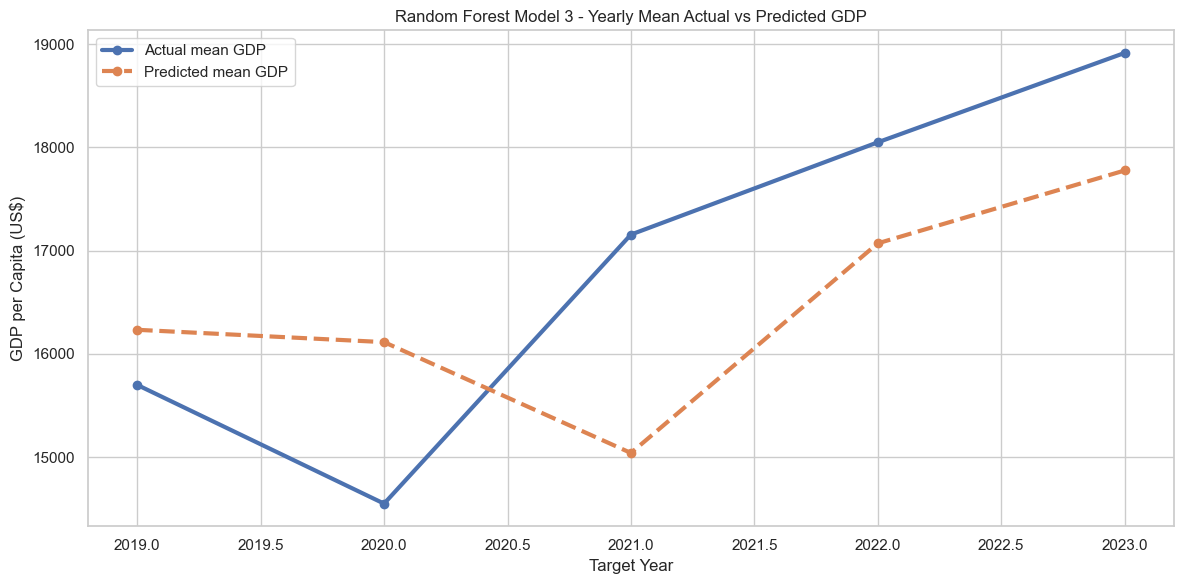

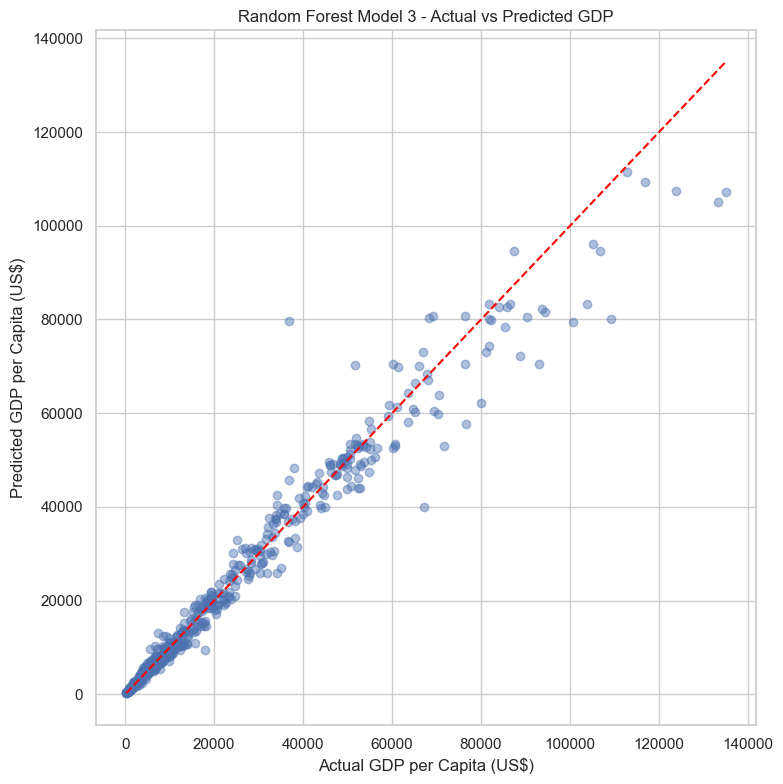

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["actual_mean_gdp"],
    marker="o",
    linewidth=3,
    label="Actual mean GDP",
)
plt.plot(
    yearly_summary_df["target_year"],
    yearly_summary_df["predicted_mean_gdp"],
    marker="o",
    linewidth=3,
    linestyle="--",
    label="Predicted mean GDP",
)
plt.title("Random Forest Model 3 - Yearly Mean Actual vs Predicted GDP")
plt.xlabel("Target Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(
    test_pred_df["actual_gdp_next_year"],
    test_pred_df["predicted_gdp_next_year"],
    alpha=0.45,
)
min_val = min(
    test_pred_df["actual_gdp_next_year"].min(),
    test_pred_df["predicted_gdp_next_year"].min(),
)
max_val = max(
    test_pred_df["actual_gdp_next_year"].max(),
    test_pred_df["predicted_gdp_next_year"].max(),
)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.title("Random Forest Model 3 - Actual vs Predicted GDP")
plt.xlabel("Actual GDP per Capita (US$)")
plt.ylabel("Predicted GDP per Capita (US$)")
plt.tight_layout()
plt.show()

In [13]:
importance_df = pd.DataFrame(
    {
        "feature": X_train_full.columns,
        "importance": final_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

importance_df.head(25)

,feature,importance
0,log_gdp_per_capita,0.8095
2,life_expectancy_years,0.1568
5,internet_users_pct_clean,0.0243
15,wb_region_Sub_Saharan_Africa_,0.0030
4,unemployment_pct_clean,0.0022
1,log_population_total,0.0013
8,year_trend,0.0011
3,inflation_pct_clean,0.0010
10,wb_region_Europe_and_Central_Asia,0.0003
11,wb_region_Latin_America_and_Caribbean_,0.0002


/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_68152/3556180853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


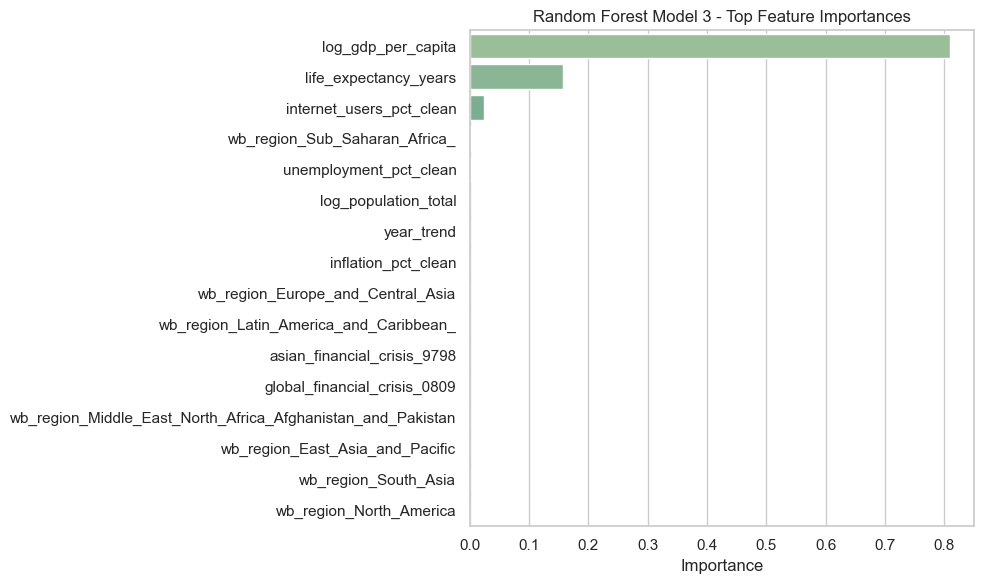

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature",
    palette="crest",
)
plt.title("Random Forest Model 3 - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [15]:
metrics_df.to_csv(OUTPUT_DIR / "gdp_random_forest_model_3_metrics.csv", index=False)
train_pred_df.to_csv(OUTPUT_DIR / "gdp_random_forest_model_3_train_predictions.csv", index=False)
test_pred_df.to_csv(OUTPUT_DIR / "gdp_random_forest_model_3_test_predictions.csv", index=False)
yearly_summary_df.to_csv(OUTPUT_DIR / "gdp_random_forest_model_3_yearly_summary.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "gdp_random_forest_model_3_feature_importance.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "gdp_random_forest_model_3_metrics.csv")
print(OUTPUT_DIR / "gdp_random_forest_model_3_train_predictions.csv")
print(OUTPUT_DIR / "gdp_random_forest_model_3_test_predictions.csv")
print(OUTPUT_DIR / "gdp_random_forest_model_3_yearly_summary.csv")
print(OUTPUT_DIR / "gdp_random_forest_model_3_feature_importance.csv")

Saved:
/Users/tonytony/Final Project/Data/Cleaned/gdp_random_forest_model_3_metrics.csv
/Users/tonytony/Final Project/Data/Cleaned/gdp_random_forest_model_3_test_predictions.csv
/Users/tonytony/Final Project/Data/Cleaned/gdp_random_forest_model_3_yearly_summary.csv
/Users/tonytony/Final Project/Data/Cleaned/gdp_random_forest_model_3_feature_importance.csv
